# CIFAR Image Classification using CNN (10 Classes)

In [1]:
# import relevant libraries
import os
import pandas as pd
import numpy as np
import pickle
import tensorflow as tf

In [11]:
# Creating a custom loader script to load the data into the right (32 x 32 x 3) shape
def unpickle(file):
    with open(file, 'rb') as fo:
        dict_val = pickle.load(fo, encoding='bytes')
    return dict_val

def load_cifar_batch(file_path):
    batch_dict = unpickle(file_path)
    data = batch_dict[b'data']
    labels = batch_dict[b'labels']

    # Reshaping from (10000, 3072) to (10000, 3, 32, 32) then transpose to (10000, 32, 32, 3)
    data = data.reshape(len(data), 3, 32, 32).transpose(0, 2, 3, 1)
    labels = np.array(labels)
    return data, labels

data_dir = '/content/drive/MyDrive/CIFAR Image Classification/data/cifar-10-batches-py'

# Loading all the 5 training batches
X_train_list, y_train_list = [], []
for i in range(1, 6):
    file_path = os.path.join(data_dir, f'data_batch_{i}')
    x_batch, y_batch = load_cifar_batch(file_path)
    X_train_list.append(x_batch)
    y_train_list.append(y_batch)

x_train = np.concatenate(X_train_list)
y_train = np.concatenate(y_train_list)

# Loading the test batch
x_test, y_test = load_cifar_batch(os.path.join(data_dir, 'test_batch'))

# Loading the metadata for class names
meta_dict = unpickle(os.path.join(data_dir, 'batches.meta'))
class_names = [item.decode('utf-8') for item in meta_dict[b'label_names']]

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)
print("Test labels shape:", y_test.shape)
print("Class names:", class_names)

Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000,)
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [14]:
unique_labels, counts = np.unique(y_train, return_counts=True)
print(dict(zip(unique_labels, counts)))

{np.int64(0): np.int64(5000), np.int64(1): np.int64(5000), np.int64(2): np.int64(5000), np.int64(3): np.int64(5000), np.int64(4): np.int64(5000), np.int64(5): np.int64(5000), np.int64(6): np.int64(5000), np.int64(7): np.int64(5000), np.int64(8): np.int64(5000), np.int64(9): np.int64(5000)}


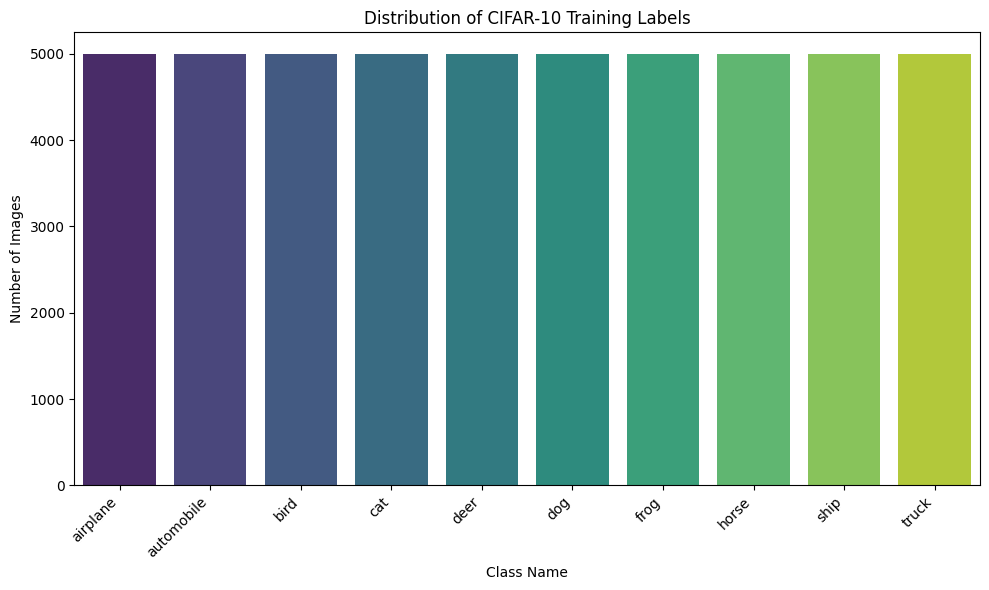

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for plotting
label_counts_df = pd.DataFrame({
    'Class ID': unique_labels,
    'Count': counts,
    'Class Name': [class_names[i] for i in unique_labels]
})

plt.figure(figsize=(10, 6))
sns.barplot(x='Class Name', y='Count', hue='Class Name', data=label_counts_df, palette='viridis', legend=False)
plt.title('Distribution of CIFAR-10 Training Labels')
plt.xlabel('Class Name')
plt.ylabel('Number of Images')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [18]:
x_train

array([[[[ 59,  62,  63],
         [ 43,  46,  45],
         [ 50,  48,  43],
         ...,
         [158, 132, 108],
         [152, 125, 102],
         [148, 124, 103]],

        [[ 16,  20,  20],
         [  0,   0,   0],
         [ 18,   8,   0],
         ...,
         [123,  88,  55],
         [119,  83,  50],
         [122,  87,  57]],

        [[ 25,  24,  21],
         [ 16,   7,   0],
         [ 49,  27,   8],
         ...,
         [118,  84,  50],
         [120,  84,  50],
         [109,  73,  42]],

        ...,

        [[208, 170,  96],
         [201, 153,  34],
         [198, 161,  26],
         ...,
         [160, 133,  70],
         [ 56,  31,   7],
         [ 53,  34,  20]],

        [[180, 139,  96],
         [173, 123,  42],
         [186, 144,  30],
         ...,
         [184, 148,  94],
         [ 97,  62,  34],
         [ 83,  53,  34]],

        [[177, 144, 116],
         [168, 129,  94],
         [179, 142,  87],
         ...,
         [216, 184, 140],
        

### Preprocessing the Images

In [19]:
# Normalizing the pixel values and convert to float32
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [20]:
x_train

array([[[[0.23137255, 0.24313726, 0.24705882],
         [0.16862746, 0.18039216, 0.1764706 ],
         [0.19607843, 0.1882353 , 0.16862746],
         ...,
         [0.61960787, 0.5176471 , 0.42352942],
         [0.59607846, 0.49019608, 0.4       ],
         [0.5803922 , 0.4862745 , 0.40392157]],

        [[0.0627451 , 0.07843138, 0.07843138],
         [0.        , 0.        , 0.        ],
         [0.07058824, 0.03137255, 0.        ],
         ...,
         [0.48235294, 0.34509805, 0.21568628],
         [0.46666667, 0.3254902 , 0.19607843],
         [0.47843137, 0.34117648, 0.22352941]],

        [[0.09803922, 0.09411765, 0.08235294],
         [0.0627451 , 0.02745098, 0.        ],
         [0.19215687, 0.10588235, 0.03137255],
         ...,
         [0.4627451 , 0.32941177, 0.19607843],
         [0.47058824, 0.32941177, 0.19607843],
         [0.42745098, 0.28627452, 0.16470589]],

        ...,

        [[0.8156863 , 0.6666667 , 0.3764706 ],
         [0.7882353 , 0.6       , 0.13333334]

In [21]:
x_test

array([[[[0.61960787, 0.4392157 , 0.19215687],
         [0.62352943, 0.43529412, 0.18431373],
         [0.64705884, 0.45490196, 0.2       ],
         ...,
         [0.5372549 , 0.37254903, 0.14117648],
         [0.49411765, 0.35686275, 0.14117648],
         [0.45490196, 0.33333334, 0.12941177]],

        [[0.59607846, 0.4392157 , 0.2       ],
         [0.5921569 , 0.43137255, 0.15686275],
         [0.62352943, 0.44705883, 0.1764706 ],
         ...,
         [0.53333336, 0.37254903, 0.12156863],
         [0.49019608, 0.35686275, 0.1254902 ],
         [0.46666667, 0.34509805, 0.13333334]],

        [[0.5921569 , 0.43137255, 0.18431373],
         [0.5921569 , 0.42745098, 0.12941177],
         [0.61960787, 0.43529412, 0.14117648],
         ...,
         [0.54509807, 0.38431373, 0.13333334],
         [0.50980395, 0.37254903, 0.13333334],
         [0.47058824, 0.34901962, 0.12941177]],

        ...,

        [[0.26666668, 0.4862745 , 0.69411767],
         [0.16470589, 0.39215687, 0.5803922 ]

### Building the CNN model

In [41]:
cnn = tf.keras.models.Sequential() # Initializing the CNN
cnn.add(tf.keras.layers.Input(shape=(32, 32, 3))) # Defining the input shape

cnn.add(tf.keras.layers.RandomFlip("horizontal")) # Adding Data Augmentation
cnn.add(tf.keras.layers.RandomRotation(0.1))

# Adding the convolutaional layers annd Pooling
# Block1
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# Block2
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# Block3
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())
cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# # Block4
# cnn.add(tf.keras.layers.Conv2D(filters=128, kernel_size=3, activation='relu'))
# cnn.add(tf.keras.layers.MaxPool2D(pool_size=2, strides=2))

# Using Global Average Pooling to cut down parameters
cnn.add(tf.keras.layers.GlobalAveragePooling2D())

# Flattening
cnn.add(tf.keras.layers.Flatten())

# Dense Classifier
cnn.add(tf.keras.layers.Dense(units=256, activation='relu'))
cnn.add(tf.keras.layers.BatchNormalization())

# Adding a Dropout layer
cnn.add(tf.keras.layers.Dropout(0.5))

# Output Layer
cnn.add(tf.keras.layers.Dense(units=10, activation='softmax'))

In [42]:
%%time

from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Training the CNNN
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

# Add callbacks
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

model = cnn.fit(x_train, y_train,
                validation_data=(x_test, y_test),
                epochs=100,
                shuffle=True,
                batch_size=64,
                callbacks=callbacks)
model

Epoch 1/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 24s 22ms/step - accuracy: 0.4114 - loss: 1.7365 - val_accuracy: 0.5006 - val_loss: 1.4620 - learning_rate: 0.0010
Epoch 2/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.5816 - loss: 1.1755 - val_accuracy: 0.5664 - val_loss: 1.3137 - learning_rate: 0.0010
Epoch 3/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.6514 - loss: 0.9938 - val_accuracy: 0.6704 - val_loss: 0.9628 - learning_rate: 0.0010
Epoch 4/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 21ms/step - accuracy: 0.6973 - loss: 0.8724 - val_accuracy: 0.6074 - val_loss: 1.2066 - learning_rate: 0.0010
Epoch 5/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 17s 22ms/step - accuracy: 0.7216 - loss: 0.8059 - val_accuracy: 0.6592 - val_loss: 1.0575 - learning_rate: 0.0010
Epoch 6/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7428 - loss: 0.7460 - val_accuracy: 0.7266 - val_loss: 0.8263 - learning_rate: 0.0010
Epoch 7/100
782/782 ━━━━━━━━━━━━━━━━━━━━ 16s 21ms/step - accuracy: 0.7

##### Plotting the learning curve

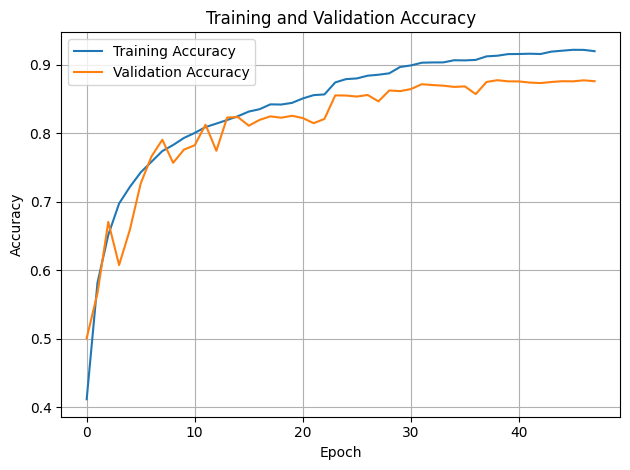

In [45]:
# Plot for accuracy
plt.plot(model.history['accuracy'], label='Training Accuracy')
plt.plot(model.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/CIFAR Image Classification/plots/Training and Validation Accuracy.png')
plt.show()

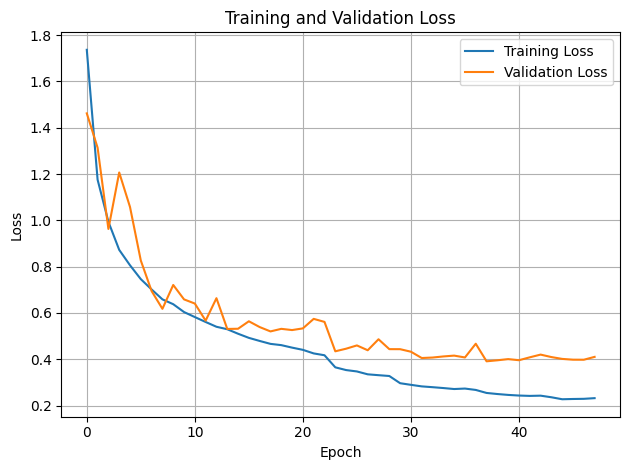

In [46]:
# Plot for loss
plt.plot(model.history['loss'], label='Training Loss')
plt.plot(model.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.grid(True)
plt.savefig('/content/drive/MyDrive/CIFAR Image Classification/plots/Training and Validation Loss.png')
plt.show()

In [47]:
# Save the model
from joblib import dump, load
dump(cnn, '/content/drive/MyDrive/CIFAR Image Classification/models/cnn_image_classification_model.joblib')

['/content/drive/MyDrive/CIFAR Image Classification/models/cnn_image_classification_model.joblib']

In [49]:
test_loss, test_accuracy = cnn.evaluate(x_test, y_test)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8748 - loss: 0.3912
Test Loss: 0.3912
Test Accuracy: 87.48%


##### Testing the model with custom images

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


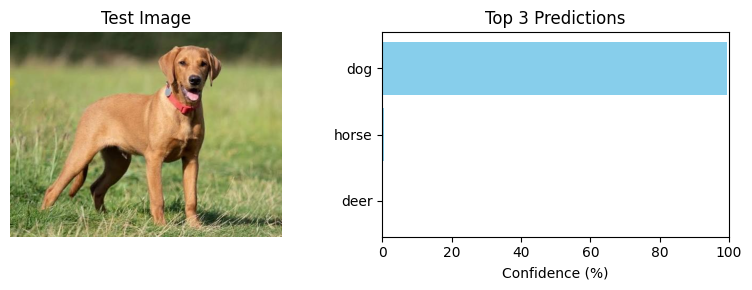

File: dog.jpg -> Top Guess: dog (99.41%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


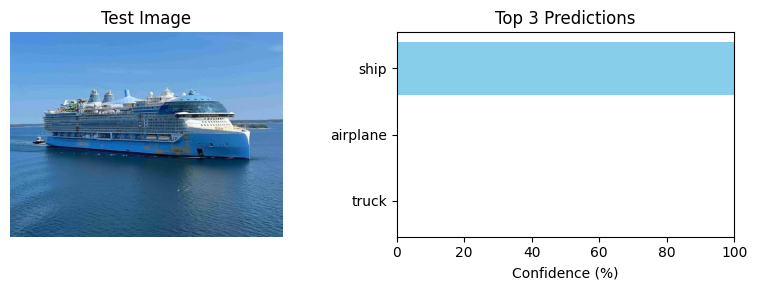

File: ship.jpg -> Top Guess: ship (99.83%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


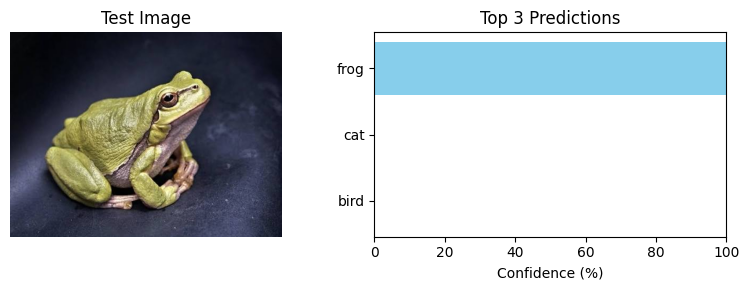

File: frog.jpg -> Top Guess: frog (100.00%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


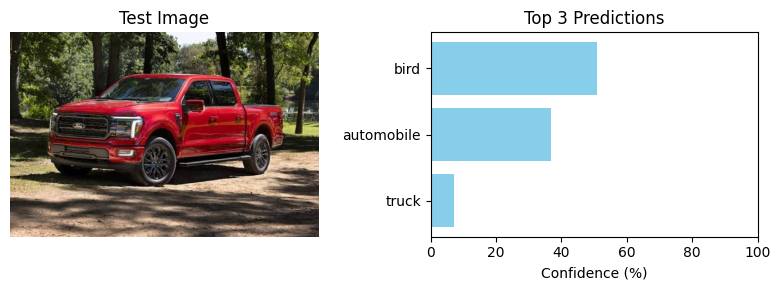

File: truck.jpg -> Top Guess: bird (50.94%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step


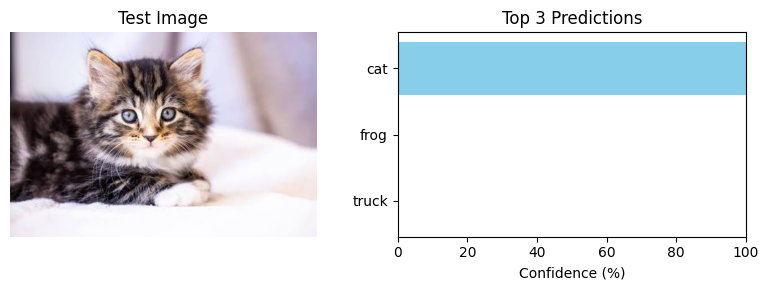

File: cat.jpg -> Top Guess: cat (99.89%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step


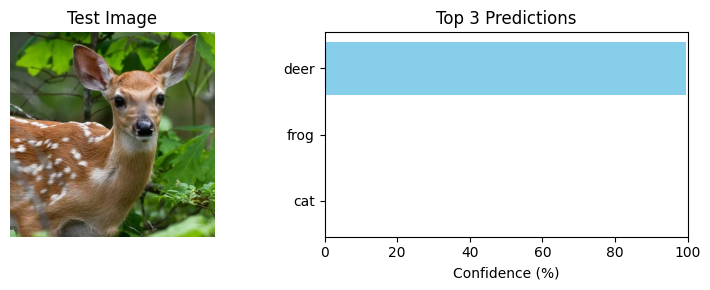

File: deer.jpg -> Top Guess: deer (99.67%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step


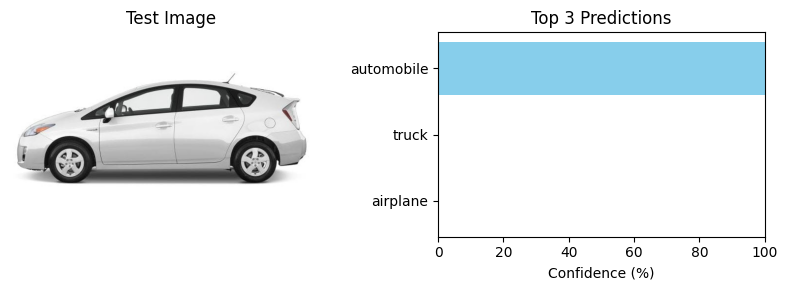

File: Automobile.jpg -> Top Guess: automobile (100.00%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


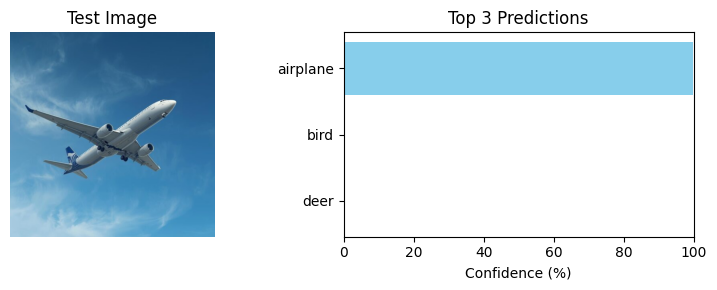

File: plane.jpg -> Top Guess: airplane (99.62%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


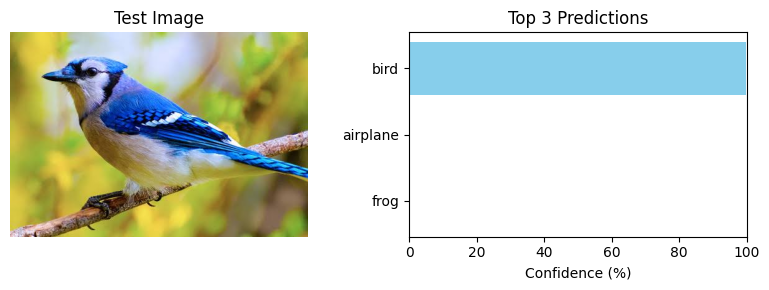

File: bird.jpg -> Top Guess: bird (99.92%)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


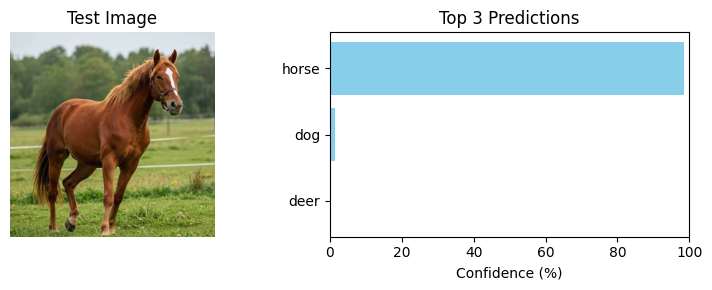

File: horse.jpg -> Top Guess: horse (98.49%)



In [60]:
from tensorflow.keras.preprocessing import image

test_folder = '/content/drive/MyDrive/CIFAR Image Classification/data/cifar-10-batches-py/test_images'
top_n = 3

for file_name in os.listdir(test_folder):
    # Checking for common image extensions
    if file_name.lower().endswith(('png', 'jpg', 'jpeg')):
        img_path = os.path.join(test_folder, file_name)

        # converting to 32 x 32
        img = image.load_img(img_path, target_size=(32, 32))

        # Converting image to a numpy array
        img_array = image.img_to_array(img)

        # Normalizing and rescaling
        img_array = img_array.astype('float32')/255.0

        # Expanding dimensions to create a batch of size 1
        img_array = np.expand_dims(img_array, axis=0)

        # Making predictions
        predictions = cnn.predict(img_array)[0]

        top_indices = predictions.argsort()[-top_n:][::-1]
        top_values = predictions[top_indices] *100
        top_labels = [class_names[i] for i in top_indices]

        predicted_class_index = np.argmax(predictions)
        predicted_class_name = class_names[predicted_class_index]

        # Creating a side-by-side plot: Image on the left, Bar chart on the right
        fig, axes = plt.subplots(1, 2, figsize=(8, 3))

        # Showing the image
        axes[0].imshow(image.load_img(img_path))
        axes[0].axis('off')
        axes[0].set_title("Test Image")

        # Plotting the horizontal bar chart for top predictions
        y_pos = np.arange(top_n)
        axes[1].barh(y_pos, top_values, align='center', color='skyblue')
        axes[1].set_yticks(y_pos)
        axes[1].set_yticklabels(top_labels)
        axes[1].invert_yaxis()
        axes[1].set_xlabel('Confidence (%)')
        axes[1].set_xlim(0, 100)
        axes[1].set_title(f"Top {top_n} Predictions")
        plt.tight_layout()
        plt.show()

        print(f"File: {file_name} -> Top Guess: {top_labels[0]} ({top_values[0]:.2f}%)\n")